Task 1 Answers

MNIST is a dataset having images of handwritten digits (0 - 9). Each image in grayscale and has 784 pixels (28 x 28). It has 60,000 training images and 10,000 testing images. Each sample consists of an image and a label. The label is the correct answer that the model must predict.

Normalisation is done for images to make it easier for the model to learn certain shapes and features.

The model will take in an image and will output its prediction for the digit. Our aim is to train this model to make its prediction more and more accurate.

In [1]:
import torch

import torch.nn as nn

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# For training the model

"""

I found the correct normalisation parameters for MNIST database online. I initially did 0.5 mean and 0.5 sd and that gave me an accuracy of
99.2. So to improve it I changed it to values I found online that work better.

"""

# Btw I prefer type hints, ik it is redundant but it makes me remember what it stores

# Random rotation for training

train_transform: transforms.Compose = transforms.Compose([transforms.RandomRotation(10), transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset: datasets.MNIST = datasets.MNIST(root = "data", train = True, transform = train_transform, download = True)

print("Training data downloaded")


# For testing the model, I didn't add the random rotation as it is not used for testing data

test_transform: transforms.Compose = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

test_dataset: datasets.MNIST = datasets.MNIST(root = "data", train = False, transform = test_transform, download = True)

print("Testing data downloaded")




Training data downloaded
Testing data downloaded


In [3]:
# Training and testing data loaders

train_dataloader: DataLoader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

test_dataloader: DataLoader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

In [4]:
# Verifying a batch by printing the shape of the image and label


image, label = next(iter(train_dataloader))

print(image.shape)

print(label.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


# Ideas Tried

I have tried multiple variants before this one. Instead of putting it in comments and making it clunky, I decided to keep a history of it here.

## Trial 1

The model basically had two conv + Relu layer, two pooling, two linear steps and Relu in between. The shape changed from (1, 28, 28)
-> (64, 26, 26) -> Pooling (64, 13, 13) -> Conv + Relu (64, 11, 11) -> Pooling (64, 5, 5)

Linear (1600) -> Relu -> Linear (128) -> Relu -> Linear (10)

This worked good with lr of 0.001 and gave an accuracy of 99.2.

## Trial 2

I wanted to increase the accuracy a bit more and read about dropout, this disables random neurons during training to prevent the model from
memorising the data. So I added a Dropout layer before Linear to 10. I made first Conv + Relu to 32 channels and second to 64 channels. I also added one more Conv + Relu step. The end shape is (64, 4, 4). The Linear step is from 1024 to 256 to 128 to 10. I kept lr at 0.001.

This gave me an accuracy of 99.36.

## Trial 3

I changed nothing in the model. I used standard normalisation parameters online instead of 0.5.

This gave me an accuracy of 99.38.


## Trial 4

I changed the lr to 0.0007, hoping maybe the learning rate was too fast. But this was too much of a drop and it reduced the accuracy
to 99.32.


## Trial 5

Finally, I set the lr to 0.0009 and kept a dynamic epoch system to train, where the training stops once learning doesn't improve by much for 7 epochs. 

This gave me an accuracy of 99.46.

## Trial 6
I added an lr scheduler, this increased the accuracy from 99.46 to 99.53.

In [5]:
# --- The Model ---

"""

We put the (1, 28, 28) image to conv layer with kernel size 3, stride 1 and 32 channels. This gives us (32, 26, 26). Now we apply ReLu and 
 
then go for pooling. We then put it through a conv layer to get (32, 24, 24). We pool with a kernel size 2 and stride 2 to get (32, 12, 12). 

We then apply conv layer with kernel size 3, stride 1 and 64 channels to get (64, 10, 10). We then apply ReLu. We then apply a conv layer to 

get (64, 8, 8). We pool again with kernel size 2 and stride 2 to get (64, 4, 4). Then we flatten to get 1024 features. We then linear to 256, 

then to 128 and then to 10. Between the linear layers we add ReLU to keep the transformation complex. Dropout is to prevent the model 

from memorising the data.


"""

class DigitCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net: nn.Sequential = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size = 3),
            nn.ReLU(),
            nn.MaxPool2d(2, stride = 2),
            nn.Conv2d(32, 64, kernel_size = 3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size = 3),
            nn.ReLU(),
            nn.MaxPool2d(2, stride = 2),
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128, 10)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        return self.net(x)



In [6]:
device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model: DigitCNN = DigitCNN().to(device)

criterion: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

"""

I initially tried lr of 0.001. Then I changed it to 0.0007. That was too slow, accuracy went from 99.38 to 99.32. So I increased it to a

value of 0.0009. This gave me my max of 99.46.


"""

optimizer: torch.optim.Adam = torch.optim.Adam(model.parameters(), lr = 0.0009)

# Task - Writing The Training Loop

To write the training loop we need to choose three things

1) The optimizer

2) The loss function

3) Number of eopchs to train


Based on the information from the docs I have made the following conclusions

The model will train on the Adam optimizer. The model will use the CrossEntropyLoss function for loass calculation. It is basically 
-sum(y_i log(p_i)). For one hot encoded values, this reduces to -log(p_i). Now here the function expects logits and not probabilities,
which makes it different from NLL, which takes probabilities. Meaning for NLL, wee have to use softmax but CrossEntropyLoss does that for us. I plan to write two train functions, one for a fixed number of epochs and the other for a dynamic amount till the model doesn't learn anything more than delta from our best loss.


Also, as an update to all my previous comments, I did not include an LR Scheduler. Now I will include one. I choose the Cosine Annealing one which modifies the learning rate as follows

lr = lr_min + (lr_max - lr_min) * (1 + cos(pi * t / T)) / 2




In [7]:

def train_flat(patience: int = 7, delta: float = 1e-3) -> list[float]:

    """
    
    The function that trains the model for a dynamic number of epoch untill there isn't a feasable decrease in loss.

    Args:
        patience (int): The amount of epochs to wait for a meaningful decrease in loss.
        delta (float): The difference in loss required from the best loss to call the decrease meaningful.

    Returns:
        Average loss list
    
    """

    model.train()

    """

    I don't know if there is a better way to do this, but I am training the model untill the loss reduction becomes lower than the best minus

    small delta of 1e-3 for 7 epochs consecutively. I keep track of it with these variables. Also, maybe there are better values for lr and

    other params which I can find with more trial and error, but this takes 28 mins to run, and I have a human patience limit too ;)
    
    
    EDIT: I did not run it on GPU, oopsie :(

    I made the changes needed to fix that.
    
    """

    best_loss: float = float("inf")

    epoch: int = 0

    scheduler: torch.optim.lr_scheduler.CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 50, eta_min = 1e-6)

    list_avg: list[float] = []

    inital_patience: int = patience

    while (patience > 0):

        epoch += 1

        losses: list[float] = []

        for images, labels in train_dataloader:

            optimizer.zero_grad()

            labels = labels.to(device)

            images = images.to(device)

            outputs: torch.Tensor = model(images)

            outputs = outputs.to(device)

            loss: torch.Tensor = criterion(outputs, labels)

            losses.append(loss.item())

            loss.backward()

            optimizer.step()

        scheduler.step()

        avg_loss: float = sum(losses) / len(losses)

        if (avg_loss < best_loss - delta):

            best_loss = avg_loss

            patience = inital_patience

        else:

            patience -= 1

        list_avg.append(avg_loss)

        print(f"Epoch {epoch}: Average loss is {avg_loss}")
    
    return list_avg



In [8]:
def train(num_epochs: int = 20) -> list[float]:

    """
    
    The function that trains the model for a fixed number of epochs.

    Args:
        num_epochs (int): The number of epochs the model must be trained for

    Returns:
        Average loss list
    
    """

    model.train()

    list_avg: list[float] = []

    for epoch in range(num_epochs):

        losses: list[float] = []

        for images, labels in train_dataloader:

            labels = labels.to(device)

            images = images.to(device)

            optimizer.zero_grad()

            outputs: torch.Tensor = model(images)

            outputs = outputs.to(device)

            loss: torch.Tensor = criterion(outputs, labels)

            losses.append(loss.item())

            loss.backward()

            optimizer.step()

        avg_loss: float = sum(losses) / len(losses)

        list_avg.append(avg_loss)

        print(f"Epoch {epoch}: Average training loss is {avg_loss}")

    return list_avg



In [9]:
def test(print_res: bool = True) -> tuple[float, list[torch.Tensor], list[int], list[float]]:

    """
    
    The function that tests the model

    Returns:
        Tuple having average loss, wrong images, wrong labels and wrong

    """

    model.eval()

    correct: int = 0

    total: int = 0

    wrong_images: list[torch.Tensor] = []

    wrong_labels: list[int] = []

    wrong_predictions: list[float] = []

    list_avg: list[float] = []

    with torch.no_grad():

        for images, labels in test_dataloader:

            images = images.to(device)

            labels = labels.to(device)

            total += labels.shape[0]

            outputs: torch.Tensor = model(images)

            outputs = outputs.to(device)

            list_avg.append(criterion(outputs, labels).item())

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
        
            wrong_mask: torch.Tensor = predicted != labels

            for i in range(labels[wrong_mask].shape[0]):

                wrong_labels.append(labels[wrong_mask][i].item())

                wrong_predictions.append(predicted[wrong_mask][i].item())

                wrong_images.append(images[wrong_mask][i].squeeze(0))

    # Best accuracy I got is 99.46

    if print_res:

        print(f"Total images seen: {total}")

        print(f"Correct results: {correct}")

        print(f"Overall accuracy: {(correct / total):.4f}")

    return sum(list_avg) / len(list_avg), wrong_images, wrong_labels, wrong_predictions



# Why Did I Choose To Save The State Dict Only?

Saving the state dict saves the model parameters, like the weights and biases for reach layer. On the other hand, saving the entire model is like saving the Python object. If we change the class or move it, the loading fails. But the advantage of saving the state dict is that we just need to initialize the model to use it. Hence I picked this method of saving

In [10]:
def save_model() -> None:

    """
    
    This function is to only save the model.
    
    """

    torch.save(model.state_dict(), "mnist.pt")

In [11]:
def save_training() -> None:

    """
    
    This function is to save the model to continue training.
    
    """

    torch.save({"model" : model.state_dict(),
                "optimizer": optimizer.state_dict()}, "mnist_train.pt")

In [ ]:
# To load the model itself

device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DigitCNN().to(device)

state_dict = torch.load("mnist.pth")

model.load_state_dict(state_dict)

model.eval()

In [ ]:
# To load the model for training

device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("mnist_train.pt")

model = DigitCNN().to(device)

model.load_state_dict(checkpoint["model"])

optimizer = torch.optim.Adam(model.parameters())

optimizer.load_state_dict(checkpoint["optimizer"])

model.train()

# After we load the model we need to train it. We can also directly run the test script. I have saved the best model so far

test_image, label = test_dataset[0]

with torch.no_grad():

    output = model(test_image.unsqueeze(0).to(device))

    prediction = output.argmax(dim=1).item()

    plt.imshow(test_image.squeeze(), cmap="gray")

    plt.title(f"Prediction: {prediction}")
    
    plt.show()



In [12]:
# We train the model here

train_loss_avg: list[float] = train_flat()

save_training()

Epoch 1: Average loss is 0.18051427328447278
Epoch 2: Average loss is 0.05790007589901212
Epoch 3: Average loss is 0.04435127133566604
Epoch 4: Average loss is 0.03590788423186858
Epoch 5: Average loss is 0.029122366461518303
Epoch 6: Average loss is 0.025876982211732173
Epoch 7: Average loss is 0.022996486840351056
Epoch 8: Average loss is 0.020196658854547033
Epoch 9: Average loss is 0.01933615606865982
Epoch 10: Average loss is 0.01642095521322329
Epoch 11: Average loss is 0.015831777544446483
Epoch 12: Average loss is 0.013150557056281292
Epoch 13: Average loss is 0.013629830798266964
Epoch 14: Average loss is 0.012189911543456841
Epoch 15: Average loss is 0.011811526852212508
Epoch 16: Average loss is 0.010244286133766174
Epoch 17: Average loss is 0.008726839048800497
Epoch 18: Average loss is 0.007997051065397465
Epoch 19: Average loss is 0.009249206185829575
Epoch 20: Average loss is 0.0076213157572724965
Epoch 21: Average loss is 0.006123190949756657
Epoch 22: Average loss is 0

Total images seen: 10000
Correct results: 9953
Overall accuracy: 0.9953


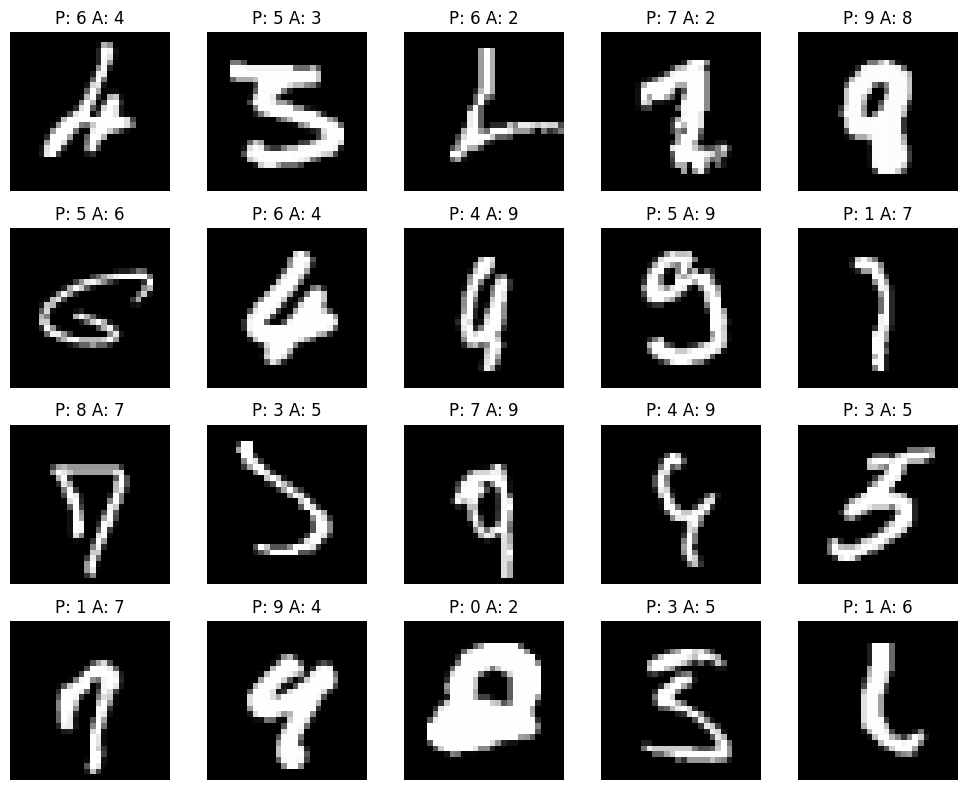

In [13]:
# We test the model here

_, wrong_images, wrong_labels, wrong_predictions = test()

# Showing first 20 mistakes

fig, axes = plt.subplots(4, 5, figsize = (10, 8))

for i, ax in enumerate(axes.flat):

    if (i >= len(wrong_labels)):

        break

    img: torch.Tensor = wrong_images[i]

    img = img.cpu()

    img = img * 0.3081 + 0.1307

    ax.imshow(img, cmap = "gray")

    ax.set_title(f"P: {wrong_predictions[i]} A: {wrong_labels[i]}")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# To plot training and testing loss


test_loss_avg: list[float] = []

train_loss_avg = []

for epoch in range(40):

    train_loss = train(1)

    test_loss, _, _, _ = test(False)

    train_loss_avg.extend(train_loss)

    test_loss_avg.append(test_loss)

    print(f"Epoch {epoch + 1}: Training loss: {train_loss[0]:.4f}, Testing loss: {test_loss:.4f}")

plt.plot(train_loss_avg, label = "Training loss", color = "orange")

plt.plot(test_loss_avg, label = "Testing loss", color = "blue")

plt.show()

From the graph we can say that there is overfitting

The training loss decreased steadily from 0.1740 to 0.0108. The testing loss decreased rapidly during the first six epochs, reaching a minimum value of 0.0239, after which it fluctuated without further improvement. This means that the model learned the features of the dataset early in training and began to show mild overfitting during later epochs.

To improve the accuracy I would

1) Increase the number of layers
2) Introduce more dorpout layers to reduce overfitting
3) Optimize the number of epochs to train